In [1]:
!pip install rdkit-pypi
!pip install pandas numpy tensorflow

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 250k_rndm_zinc_drugs_clean_3.csv to 250k_rndm_zinc_drugs_clean_3.csv


In [4]:
import pandas as pd

df = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
smiles = df['smiles'].dropna().tolist()

print(len(smiles))

249455


In [5]:
!pip install rdkit
from rdkit import Chem

def is_valid(s):
    return Chem.MolFromSmiles(s) is not None

smiles = [s for s in smiles if is_valid(s)]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 63.0 MB/s eta 0:00:00


In [6]:
PAD = '_'

chars = sorted(list(set(''.join(smiles)) | {PAD}))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

In [7]:
max_len = 30
batch_size = 256

In [8]:
import numpy as np

def data_generator(smiles, batch_size):
    while True:
        X_batch = []
        y_batch = []

        for s in smiles:
            for i in range(min(len(s)-1, 10)):  # limit expansion
                seq = s[:i+1].ljust(max_len, PAD)
                X_batch.append([char_to_idx[c] for c in seq])
                y_batch.append(char_to_idx[s[i+1]])

                if len(X_batch) == batch_size:
                    yield np.array(X_batch), np.array(y_batch)
                    X_batch, y_batch = [], []

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

model = Sequential([
    Embedding(len(chars), 64, input_length=max_len),
    LSTM(128),
    Dense(len(chars), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
steps_per_epoch = len(smiles) // batch_size

model.fit(
    data_generator(smiles, batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=50
)

Epoch 1/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 2.3998
Epoch 2/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.0978
Epoch 3/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.9471
Epoch 4/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.8951
Epoch 5/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8702
Epoch 6/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8539
Epoch 7/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.8457
Epoch 8/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8335
Epoch 9/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8274
Epoch 10/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8214
Epoch 11/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.8164
Epoch 12/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8124
Epoch 13/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8099
Epoch 14/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8089
Epoch 15/50
974/974 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - l

In [11]:
model.save("molecule_model.h5")

In [12]:
allowed_chars = set(char_to_idx.keys())

def clean_smiles(sm):
    return ''.join([c for c in sm if c in allowed_chars])

In [13]:
import numpy as np


# Sampling function (stable)
def sample(preds, temperature=0.3):
    preds = np.log(preds + 1e-8) / temperature
    preds = np.exp(preds)
    preds = preds / np.sum(preds)
    return np.random.choice(len(preds), p=preds)




# Generate SMILES (with strict control)
def generate_smiles(seed, length=30):
    s = seed


    for _ in range(length):
        seq = s[:max_len].ljust(max_len, PAD)
        x = np.array([[char_to_idx.get(c, 0) for c in seq]])


        preds = model.predict(x, verbose=0)[0]


        next_idx = sample(preds, temperature=0.3)
        next_char = idx_to_char[next_idx]


        # STOP CONDITIONS (VERY IMPORTANT)
        if next_char == PAD:
            break


        if next_char not in char_to_idx:
            break


        if next_char in ['[', ']', '@', '/', '\\']:
            break


        s += next_char


        if len(s) > max_len:
            break


    return s




# CLEAN FUNCTION
allowed_chars = set(char_to_idx.keys())


def clean_smiles(sm):
    return ''.join([c for c in sm if c in allowed_chars])




# SAFE SEEDS
seeds = ["CC", "CCC", "COC", "CCO"]


# GENERATE MOLECULES
generated = [clean_smiles(generate_smiles(seed=np.random.choice(seeds))) for _ in range(500)]


# REMOVE SHORT + DUPLICATES
generated = [g for g in generated if len(g) > 5]
generated = list(set(generated))


# PRINT OUTPUT
print("Generated Molecules:")
for g in generated:
    print(g)


Generated Molecules:
CCCCC(=O)N1CCN(C(=O)N)
CCOc1cc(C)cc(C(=O)Nc2cc(C(O
CC(C)(C)NC(=O)C1CCN(C(=O)N
CCCCCNC(=O)N1CC
CCCNC(=O)c1ccc(Cl)cc(C(=O)N3
COCCN1C(=O)
CCCN(CC(=O)Nc1cccc(NC(=O)Nc1nnr
CCOC(=O)c1ccc(Cl)cc(C(=O)N3C3c
CCCCCN(C)C(=O)NC(=O)c1nn1CC1S44
CCOc1ccc(NC(=O)Nc2ccc(C(=O
COC(=O)c1ccc(Cl)cc(CN2CCN3C133I
CCC(=O)N1CC
CCCCNC(=O)CN1C(=O)N(C)CC1CN33
CCOC(=O)C1=C(C(=O)N2c(C)c1nn3


CCOC(=O)C1=C(C)(N)=C(O)N(c2n))P
CC(=O)Nc1ccc(C(=O)Nc2cc(C(O
CCOC(=O)C1=C(C(=O)N2cc(C)c1nn
CCOC(=O)c1cccc(C(=O)Nc2cnc1(444
CCCCNC(=O)c1cccc(C(=O)Nc2cc3c
COC(=O)c1ccc(Cl)cc(-c2cc3-c
COC(=O)c1ccccc1NC(=O)
CCCCCCNC(=O)
COC(=O)c1ccccc1C
CCCCN(C)C(=O)NC(=O)c1nnc1C1N+
r
CCOc1ccc(C(=O)N2CCC
COC(=O)c1ccc(C(=O)Nc2cc(C(C
CCCCn1c(C)nnc1CN1CCC1)
CCCCCCNC(=O)NC(=O)c1ccc(C)1C333
COC(=O)c1cc(Cl)cc(C(=O)Nc1N3cco
COC(=O)c1ccc(Cl)cc(Cl)nn1CC1C44
CCCNC(=O)c1ccc(Cl)cc(C(=
COC(=O)c1ccc(Cl)cc(CN2CCN3C13
COC(=O)C1=C(C(=O)N2c(C)c1-n
CCCCCCNC(=O)NC(=O)c1nn1CC1C3C3+
COC(=O)C1=C(C)
CCCNC(=O)c1ccc(Cl)cc(CN2CCNHH
CCOC(=O)C1=C(C(=O)N
CCCN(

In [15]:
from rdkit import Chem


valid_raw = []

for sm in generated:
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        valid_raw.append(sm)


valid_molecules = list(set(valid_raw))
valid_molecules = [m for m in valid_molecules if len(m) > 5]

print("Valid molecules:", len(valid_molecules))
print(valid_molecules)


Valid molecules: 18
['CCOC(=O)c1ccccc1C', 'CC(C)(C)', 'COC(=O)', 'CCCCCCNC(=O)NC(=O)', 'CCCCCNC(=O)NC(=O)', 'COC(=O)c1ccccc1NC(=O)', 'CCCCCCNC(=O)', 'COC(=O)c1ccccc1C', 'CC(C)C', 'CCCCNC(=O)', 'CC(C)CCOC', 'CC(C)CC', 'CCCCN(C)C(=O)NC(=O)', 'CCOC(=O)', 'CCCCNC(=O)NC(=O)', 'CCOc1ccccc1C', 'CC(C)(C)OC(=O)', 'CCCCCNC(=O)CN1C(=O)N(C)CC1=C']


[14:07:18] SMILES Parse Error: unclosed ring for input: 'CCCCC(=O)N1CCN(C(=O)N)'
[14:07:18] SMILES Parse Error: extra open parentheses while parsing: CCOc1cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] SMILES Parse Error: check for mistakes around position 13:
[14:07:18] CCOc1cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] ~~~~~~~~~~~~^
[14:07:18] SMILES Parse Error: extra open parentheses while parsing: CCOc1cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] SMILES Parse Error: check for mistakes around position 24:
[14:07:18] c1cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] ~~~~~~~~~~~~~~~~~~~~^
[14:07:18] SMILES Parse Error: extra open parentheses while parsing: CCOc1cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] SMILES Parse Error: check for mistakes around position 26:
[14:07:18] cc(C)cc(C(=O)Nc2cc(C(O
[14:07:18] ~~~~~~~~~~~~~~~~~~~~^
[14:07:18] SMILES Parse Error: Failed parsing SMILES 'CCOc1cc(C)cc(C(=O)Nc2cc(C(O' for input: 'CCOc1cc(C)cc(C(=O)Nc2cc(C(O'
[14:07:18] SMILES Parse Error: extra open parentheses while parsing: CC(C)(C)NC(=O)C1CCN(C(=O)

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def drug_score(sm):
    mol = Chem.MolFromSmiles(sm)

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)

    score = 0
    if mw < 500: score += 1
    if logp < 5: score += 1
    if h_donors <= 5: score += 1
    if h_acceptors <= 10: score += 1

    return score / 4

In [17]:
def toxicity(sm):
    return len(sm) / 50   # simple proxy

In [18]:
results = []

for sm in valid_molecules:
    d = drug_score(sm)
    t = toxicity(sm)

    score = d - t

    results.append((sm, d, t, score))

# Sort by best score
results = sorted(results, key=lambda x: x[3], reverse=True)

# Print results
print("Final Ranked Molecules:\n")

for sm, d, t, s in results:
    print(f"Molecule: {sm}")
    print(f"Drug Score: {d:.2f}, Toxicity: {t:.2f}, Final Score: {s:.2f}")
    print("-"*40)

Final Ranked Molecules:

Molecule: CC(C)C
Drug Score: 1.00, Toxicity: 0.12, Final Score: 0.88
----------------------------------------
Molecule: COC(=O)
Drug Score: 1.00, Toxicity: 0.14, Final Score: 0.86
----------------------------------------
Molecule: CC(C)CC
Drug Score: 1.00, Toxicity: 0.14, Final Score: 0.86
----------------------------------------
Molecule: CC(C)(C)
Drug Score: 1.00, Toxicity: 0.16, Final Score: 0.84
----------------------------------------
Molecule: CCOC(=O)
Drug Score: 1.00, Toxicity: 0.16, Final Score: 0.84
----------------------------------------
Molecule: CC(C)CCOC
Drug Score: 1.00, Toxicity: 0.18, Final Score: 0.82
----------------------------------------
Molecule: CCCCNC(=O)
Drug Score: 1.00, Toxicity: 0.20, Final Score: 0.80
----------------------------------------
Molecule: CCCCCCNC(=O)
Drug Score: 1.00, Toxicity: 0.24, Final Score: 0.76
----------------------------------------
Molecule: CCOc1ccccc1C
Drug Score: 1.00, Toxicity: 0.24, Final Score: 0.76
-

In [19]:
results = []

for sm in valid_molecules:
    d = drug_score(sm)
    t = toxicity(sm)
    score = d - t

    results.append((sm, d, t, score))

# Sort by highest score
results = sorted(results, key=lambda x: x[3], reverse=True)

# BEST molecule
best = results[0]

print("\n🏆 BEST MOLECULE:")
print("Molecule:", best[0])
print("Drug Score:", round(best[1], 2))
print("Toxicity:", round(best[2], 2))
print("Final Score:", round(best[3], 2))


🏆 BEST MOLECULE:
Molecule: CC(C)C
Drug Score: 1.0
Toxicity: 0.12
Final Score: 0.88


In [20]:
print("\n--- Evaluation Metrics ---")

# 1️⃣ Validity
validity = len(valid_raw) / len(generated)
print("Validity:", round(validity, 3))

# 2️⃣ Uniqueness
uniqueness = len(set(generated)) / len(generated)
print("Uniqueness:", round(uniqueness, 3))

# 3️⃣ Novelty
train_set = set(smiles)   # your training data
novel = [m for m in valid_molecules if m not in train_set]

novelty = len(novel) / len(valid_molecules) if valid_molecules else 0
print("Novelty:", round(novelty, 3))

# 4️⃣ Average Drug Score
scores = [drug_score(m) for m in valid_molecules]
avg_score = sum(scores) / len(scores) if scores else 0

print("Avg Drug Score:", round(avg_score, 3))


--- Evaluation Metrics ---
Validity: 0.073
Uniqueness: 1.0
Novelty: 1.0
Avg Drug Score: 1.0


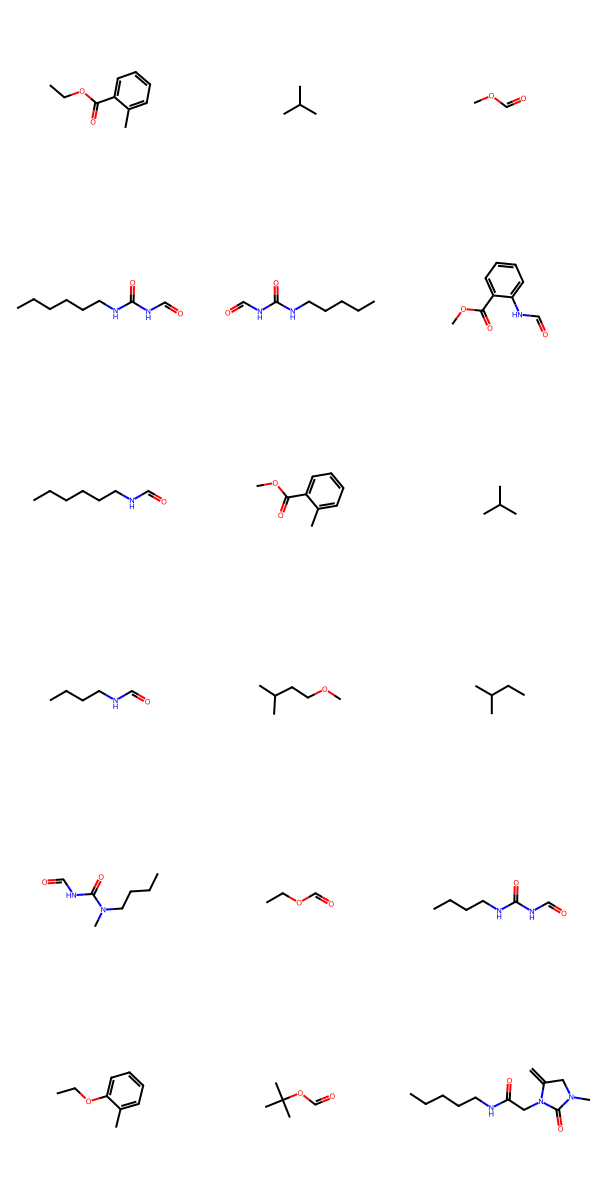

In [21]:
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(sm) for sm in valid_molecules]
Draw.MolsToGridImage(mols)

In [22]:
print("\n--- Advanced Metrics (%) ---")

total_valid = len(valid_molecules)

# 1️⃣ Drug-like %
drug_like = [m for m in valid_molecules if drug_score(m) >= 0.75]
drug_like_pct = (len(drug_like) / total_valid * 100) if total_valid else 0

# 2️⃣ Non-drug-like %
non_drug_like_pct = 100 - drug_like_pct

# 3️⃣ Average Toxicity (already a value, keep as is or convert to %)
tox_scores = [toxicity(m) for m in valid_molecules]
avg_toxicity = (sum(tox_scores) / len(tox_scores) * 100) if tox_scores else 0

# 4️⃣ Novel %
train_set = set(smiles)
novel_molecules = [m for m in valid_molecules if m not in train_set]
novel_pct = (len(novel_molecules) / total_valid * 100) if total_valid else 0

print("Drug-Like Molecules (%):", round(drug_like_pct, 2))
print("Non-Drug-Like Molecules (%):", round(non_drug_like_pct, 2))
print("Average Toxicity (%):", round(avg_toxicity, 2))
print("Novel Molecules (%):", round(novel_pct, 2))


--- Advanced Metrics (%) ---
Drug-Like Molecules (%): 100.0
Non-Drug-Like Molecules (%): 0.0
Average Toxicity (%): 27.22
Novel Molecules (%): 100.0


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("basu369victor/zinc250k")

print("Path to dataset files:", path)

100%|██████████| 8.60M/8.60M [00:00<00:00, 11.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/basu369victor/zinc250k/versions/1


In [23]:
!pip install rdkit matplotlib seaborn pandas numpy scikit-learn -q

📊 CELL 2 — Full Molecular Property Table (MW, LogP, TPSA, HBA, HBD, Rings, RotBonds)

In [24]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

rows = []
for sm in valid_molecules:
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        continue
    rows.append({
        'SMILES'         : sm,
        'MolWeight'      : round(Descriptors.MolWt(mol), 2),
        'LogP'           : round(Descriptors.MolLogP(mol), 2),
        'TPSA'           : round(rdMolDescriptors.CalcTPSA(mol), 2),
        'HBD'            : Descriptors.NumHDonors(mol),
        'HBA'            : Descriptors.NumHAcceptors(mol),
        'RotBonds'       : rdMolDescriptors.CalcNumRotatableBonds(mol),
        'AromaticRings'  : rdMolDescriptors.CalcNumAromaticRings(mol),
        'DrugScore'      : round(drug_score(sm), 3),
        'Toxicity'       : round(toxicity(sm), 3),
        'FinalScore'     : round(drug_score(sm) - toxicity(sm), 3)
    })

prop_df = pd.DataFrame(rows).sort_values('FinalScore', ascending=False).reset_index(drop=True)
print(f'Total valid molecules with properties: {len(prop_df)}')
prop_df.head(15)

Total valid molecules with properties: 18


,SMILES,MolWeight,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,DrugScore,Toxicity,FinalScore
0,CC(C)C,58.12,1.66,0.00,0,0,0,0,1.0,0.12,0.88
1,COC(=O),60.05,-0.21,26.30,0,2,1,0,1.0,0.14,0.86
2,CC(C)CC,72.15,2.05,0.00,0,0,1,0,1.0,0.14,0.86
3,CC(C)(C),58.12,1.66,0.00,0,0,0,0,1.0,0.16,0.84
4,CCOC(=O),74.08,0.18,26.30,0,2,2,0,1.0,0.16,0.84
5,CC(C)CCOC,102.18,1.68,9.23,0,1,3,0,1.0,0.18,0.82
6,CCCCNC(=O),101.15,0.53,29.10,1,1,4,0,1.0,0.20,0.80
7,CCOc1ccccc1C,136.19,2.39,9.23,0,1,2,1,1.0,0.24,0.76
8,CCCCCCNC(=O),129.20,1.31,29.10,1,1,6,0,1.0,0.24,0.76
9,CC(C)(C)OC(=O),102.13,0.96,26.30,0,2,1,0,1.0,0.28,0.72


📈 CELL 3 — Property Distribution Plots

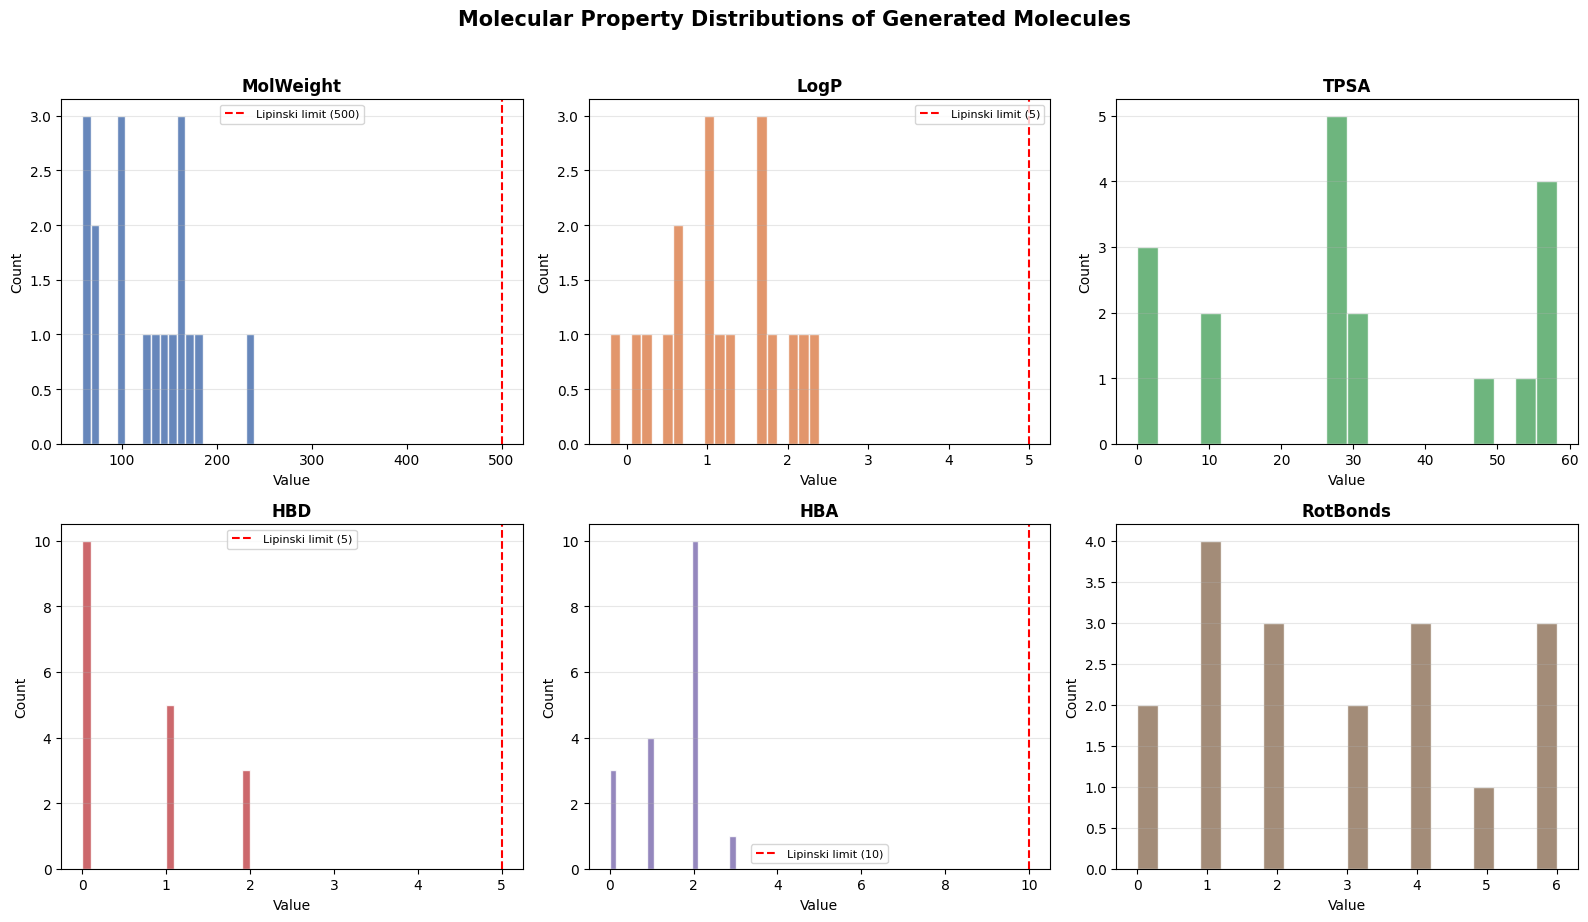

Saved: property_distributions.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

props = ['MolWeight', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds']
lipinski_limits = {
    'MolWeight': 500, 'LogP': 5, 'HBD': 5, 'HBA': 10
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for i, prop in enumerate(props):
    ax = axes[i]
    ax.hist(prop_df[prop], bins=20, color=colors[i], edgecolor='white', alpha=0.85)
    if prop in lipinski_limits:
        ax.axvline(lipinski_limits[prop], color='red', linestyle='--',
                   linewidth=1.5, label=f'Lipinski limit ({lipinski_limits[prop]})')
        ax.legend(fontsize=8)
    ax.set_title(prop, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Molecular Property Distributions of Generated Molecules',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: property_distributions.png')

🎯 CELL 4 — Drug Score vs Toxicity Scatter Plot

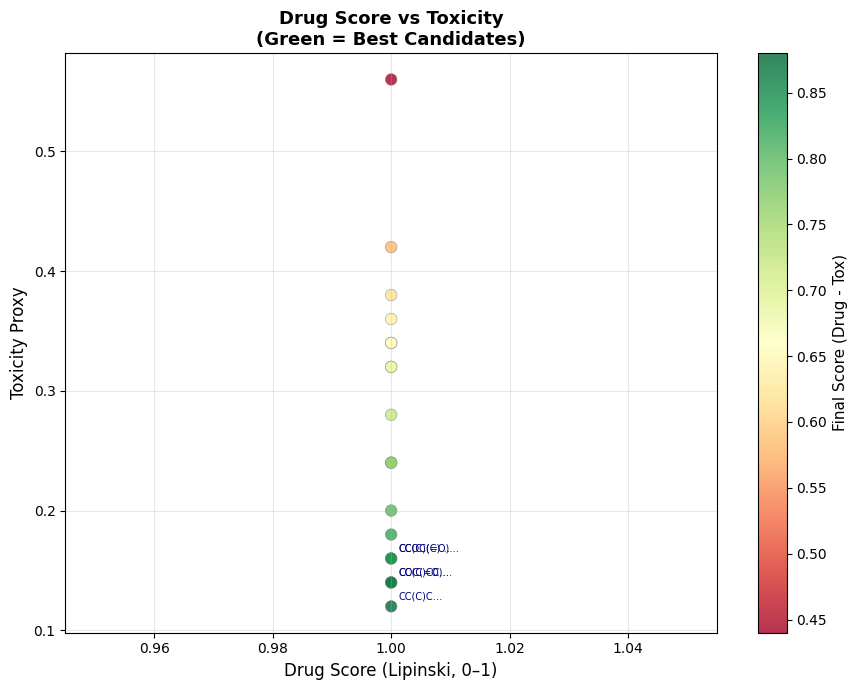

Saved: drug_vs_toxicity.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    prop_df['DrugScore'],
    prop_df['Toxicity'],
    c=prop_df['FinalScore'],
    cmap='RdYlGn',
    s=70, alpha=0.8, edgecolors='grey', linewidths=0.4
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Final Score (Drug - Tox)', fontsize=11)

# Annotate top 5
top5 = prop_df.head(5)
for _, row in top5.iterrows():
    ax.annotate(row['SMILES'][:10] + '…',
                xy=(row['DrugScore'], row['Toxicity']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, color='navy')

ax.set_xlabel('Drug Score (Lipinski, 0–1)', fontsize=12)
ax.set_ylabel('Toxicity Proxy', fontsize=12)
ax.set_title('Drug Score vs Toxicity\n(Green = Best Candidates)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drug_vs_toxicity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: drug_vs_toxicity.png')

 CELL 5 — Chemical Space Map (PCA on Morgan Fingerprints)

[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerator
[14:09:29] DEPRECATION WARNING: please use MorganGenerat

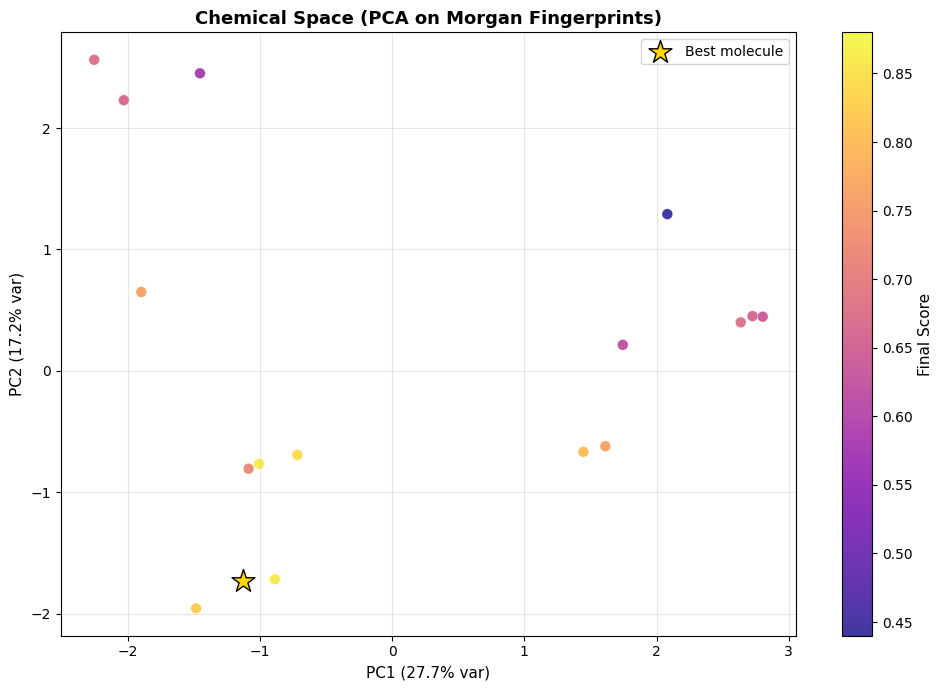

Saved: chemical_space_pca.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

fps, smiles_valid, scores = [], [], []

for _, row in prop_df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=512)
    fps.append(list(fp))
    smiles_valid.append(row['SMILES'])
    scores.append(row['FinalScore'])

X = np.array(fps)

if X.shape[0] >= 2:
    pca = PCA(n_components=2, random_state=42)
    X2d = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(X2d[:, 0], X2d[:, 1],
                    c=scores, cmap='plasma', s=60,
                    alpha=0.8, edgecolors='white', linewidths=0.3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Final Score', fontsize=11)

    # Star the best molecule
    ax.scatter(X2d[0, 0], X2d[0, 1], marker='*', s=300,
               color='gold', edgecolors='black', zorder=5, label='Best molecule')
    ax.legend(fontsize=10)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
    ax.set_title('Chemical Space (PCA on Morgan Fingerprints)', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('chemical_space_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: chemical_space_pca.png')
else:
    print('Not enough valid molecules for PCA (need at least 2).')

 CELL 6 — Property Correlation Heatmap

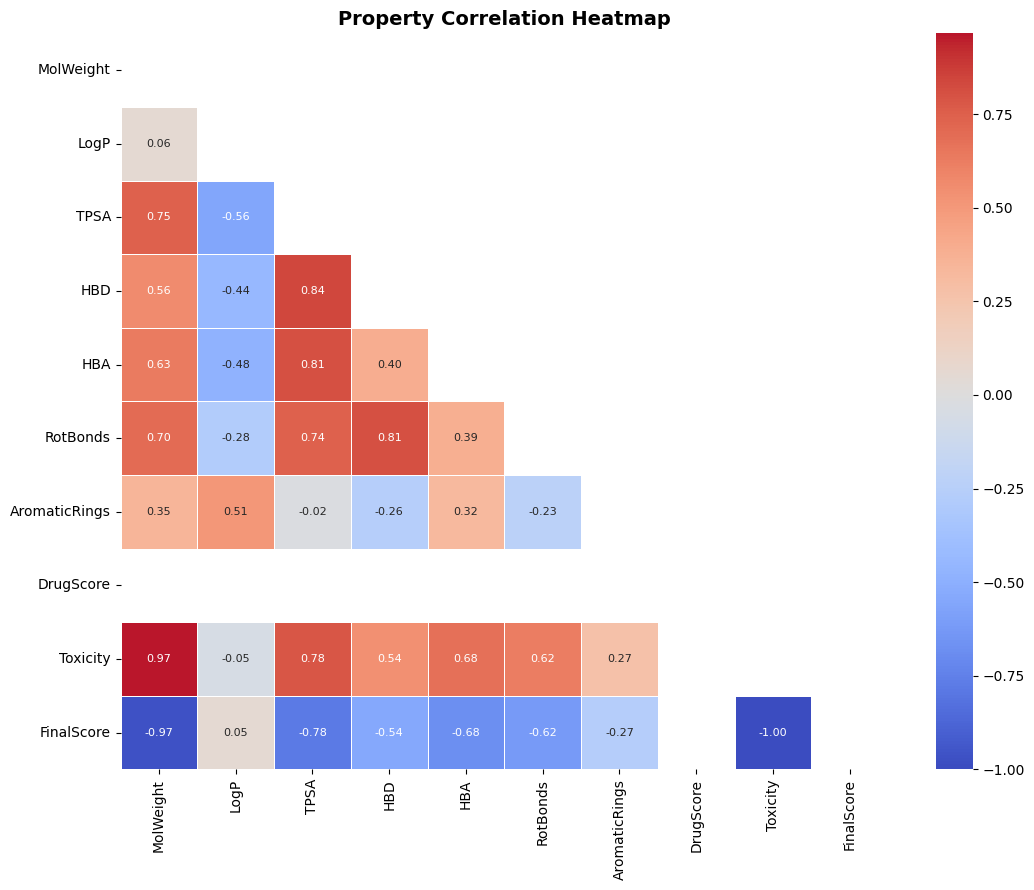

Saved: property_correlation.png


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['MolWeight','LogP','TPSA','HBD','HBA','RotBonds','AromaticRings','DrugScore','Toxicity','FinalScore']
corr = prop_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Property Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('property_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: property_correlation.png')

 CELL 7 — QED Score (Quantitative Estimate of Drug-likeness)


--- QED (Quantitative Estimate of Drug-likeness) ---
Min QED  : 0.391
Max QED  : 0.707
Mean QED : 0.495
Molecules with QED > 0.6: 4 (22.2%)


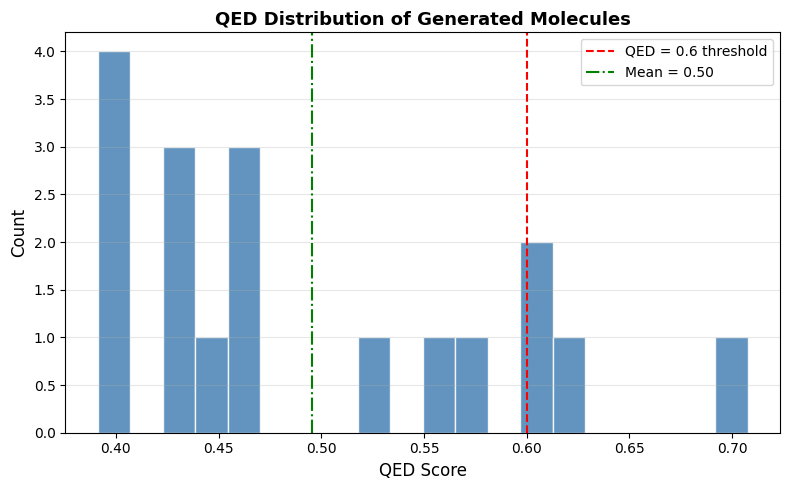

Saved: qed_distribution.png


In [29]:
from rdkit.Chem import QED
import matplotlib.pyplot as plt

qed_scores = []
for sm in valid_molecules:
    mol = Chem.MolFromSmiles(sm)
    if mol:
        qed_scores.append(QED.qed(mol))

print(f'\n--- QED (Quantitative Estimate of Drug-likeness) ---')
print(f'Min QED  : {min(qed_scores):.3f}')
print(f'Max QED  : {max(qed_scores):.3f}')
print(f'Mean QED : {sum(qed_scores)/len(qed_scores):.3f}')
print(f'Molecules with QED > 0.6: {sum(1 for q in qed_scores if q > 0.6)} ({sum(1 for q in qed_scores if q > 0.6)/len(qed_scores)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(qed_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.6, color='red', linestyle='--', linewidth=1.5, label='QED = 0.6 threshold')
ax.axvline(sum(qed_scores)/len(qed_scores), color='green', linestyle='-.',
           linewidth=1.5, label=f'Mean = {sum(qed_scores)/len(qed_scores):.2f}')
ax.set_xlabel('QED Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('QED Distribution of Generated Molecules', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('qed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qed_distribution.png')

📉 CELL 8 — Lipinski Rule Violation Breakdown (Bar Chart)

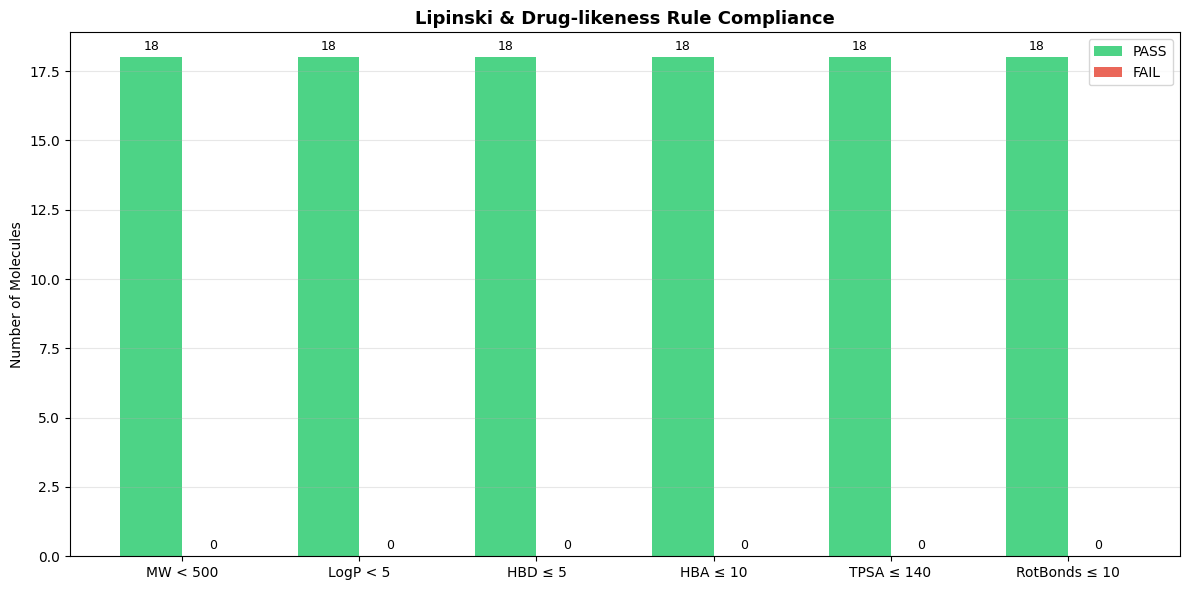

Saved: lipinski_compliance.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

rules = {
    'MW < 500'    : (prop_df['MolWeight'] < 500).sum(),
    'LogP < 5'    : (prop_df['LogP'] < 5).sum(),
    'HBD ≤ 5'     : (prop_df['HBD'] <= 5).sum(),
    'HBA ≤ 10'    : (prop_df['HBA'] <= 10).sum(),
    'TPSA ≤ 140'  : (prop_df['TPSA'] <= 140).sum(),
    'RotBonds ≤ 10': (prop_df['RotBonds'] <= 10).sum(),
}

total = len(prop_df)
labels = list(rules.keys())
pass_counts = list(rules.values())
fail_counts = [total - p for p in pass_counts]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, pass_counts, width, label='PASS', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, fail_counts, width, label='FAIL', color='#e74c3c', alpha=0.85)

ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Number of Molecules')
ax.set_title('Lipinski & Drug-likeness Rule Compliance', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lipinski_compliance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lipinski_compliance.png')

🕸 CELL 9 — Radar Chart for Top 5 Molecules

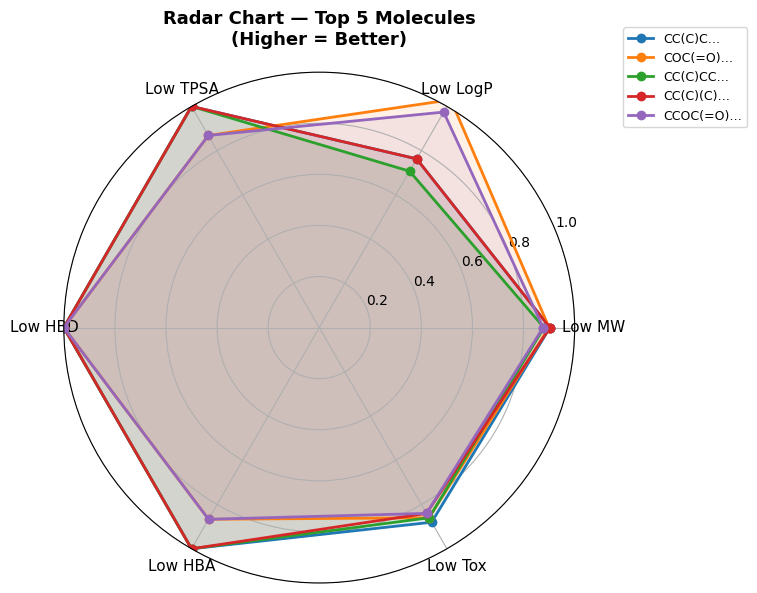

Saved: radar_top5.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize properties to [0, 1] for radar (higher = better)
top5 = prop_df.head(5).copy()

def normalize_inv(val, max_val):   # lower raw = higher score
    return max(0, 1 - val / max_val)

radar_data = []
for _, row in top5.iterrows():
    radar_data.append([
        normalize_inv(row['MolWeight'], 600),
        normalize_inv(row['LogP'], 7),
        normalize_inv(row['TPSA'], 200),
        normalize_inv(row['HBD'], 8),
        normalize_inv(row['HBA'], 15),
        normalize_inv(row['Toxicity'], 1),
    ])

categories = ['Low MW', 'Low LogP', 'Low TPSA', 'Low HBD', 'Low HBA', 'Low Tox']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

for i, (values, (_, row)) in enumerate(zip(radar_data, top5.iterrows())):
    vals = values + values[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i],
            label=row['SMILES'][:12] + '…')
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Top 5 Molecules\n(Higher = Better)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: radar_top5.png')

🔢 CELL 10 — Full Metrics Summary Dashboard


        FULL METRICS SUMMARY
  Validity (%)         : 7.3
  Uniqueness (%)       : 100.0
  Novelty (%)          : 100.0
  Drug-Like (%)        : 100.0
  Mean QED             : 0.495
  Mean DrugScore       : 1.0
  Mean Toxicity        : 0.272
  Total Generated      : 245
  Total Valid          : 18
  Novel Mols           : 18


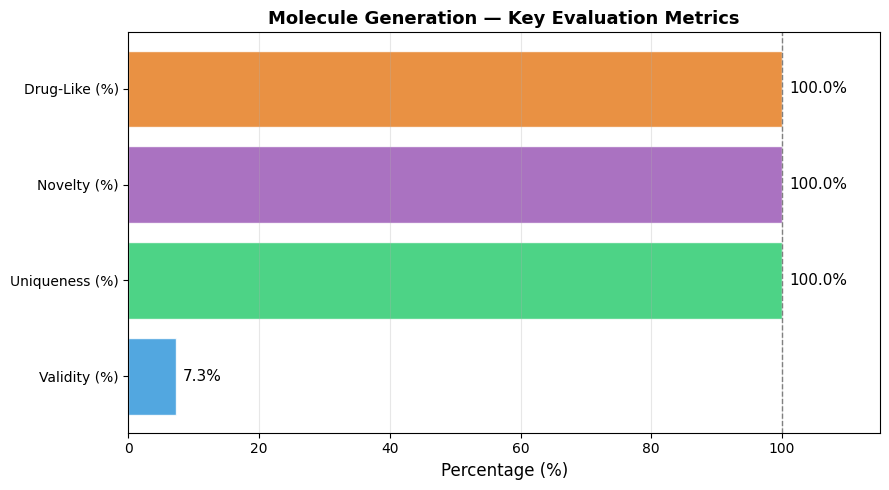

Saved: metrics_dashboard.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rdkit.Chem import QED

# ---- recompute all metrics ----
total_generated = len(generated)
validity_pct    = len(valid_raw) / total_generated * 100
uniqueness_pct  = len(set(generated)) / total_generated * 100
train_set       = set(smiles)
novel_mols      = [m for m in valid_molecules if m not in train_set]
novelty_pct     = len(novel_mols) / len(valid_molecules) * 100 if valid_molecules else 0
drug_like_mols  = [m for m in valid_molecules if drug_score(m) >= 0.75]
drug_like_pct   = len(drug_like_mols) / len(valid_molecules) * 100 if valid_molecules else 0

qeds = []
for sm in valid_molecules:
    mol = Chem.MolFromSmiles(sm)
    if mol:
        qeds.append(QED.qed(mol))
mean_qed = sum(qeds)/len(qeds) if qeds else 0

all_ds = [drug_score(m) for m in valid_molecules]
mean_drug_score = sum(all_ds)/len(all_ds) if all_ds else 0

all_ts = [toxicity(m) for m in valid_molecules]
mean_tox = sum(all_ts)/len(all_ts) if all_ts else 0

metrics = {
    'Validity (%)': round(validity_pct, 1),
    'Uniqueness (%)': round(uniqueness_pct, 1),
    'Novelty (%)': round(novelty_pct, 1),
    'Drug-Like (%)': round(drug_like_pct, 1),
    'Mean QED': round(mean_qed, 3),
    'Mean DrugScore': round(mean_drug_score, 3),
    'Mean Toxicity': round(mean_tox, 3),
    'Total Generated': total_generated,
    'Total Valid': len(valid_molecules),
    'Novel Mols': len(novel_mols),
}

print('\n' + '='*45)
print('        FULL METRICS SUMMARY')
print('='*45)
for k, v in metrics.items():
    print(f'  {k:<20} : {v}')
print('='*45)

# ---- Dashboard bar chart ----
pct_metrics = ['Validity (%)', 'Uniqueness (%)', 'Novelty (%)', 'Drug-Like (%)']
vals = [metrics[m] for m in pct_metrics]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#3498db','#2ecc71','#9b59b6','#e67e22']
bars = ax.barh(pct_metrics, vals, color=bar_colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11)
ax.set_xlim(0, 115)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_title('Molecule Generation — Key Evaluation Metrics', fontsize=13, fontweight='bold')
ax.axvline(100, color='grey', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metrics_dashboard.png')

🖼 CELL 11 — Visualize Top 12 Molecules (RDKit Grid Image)

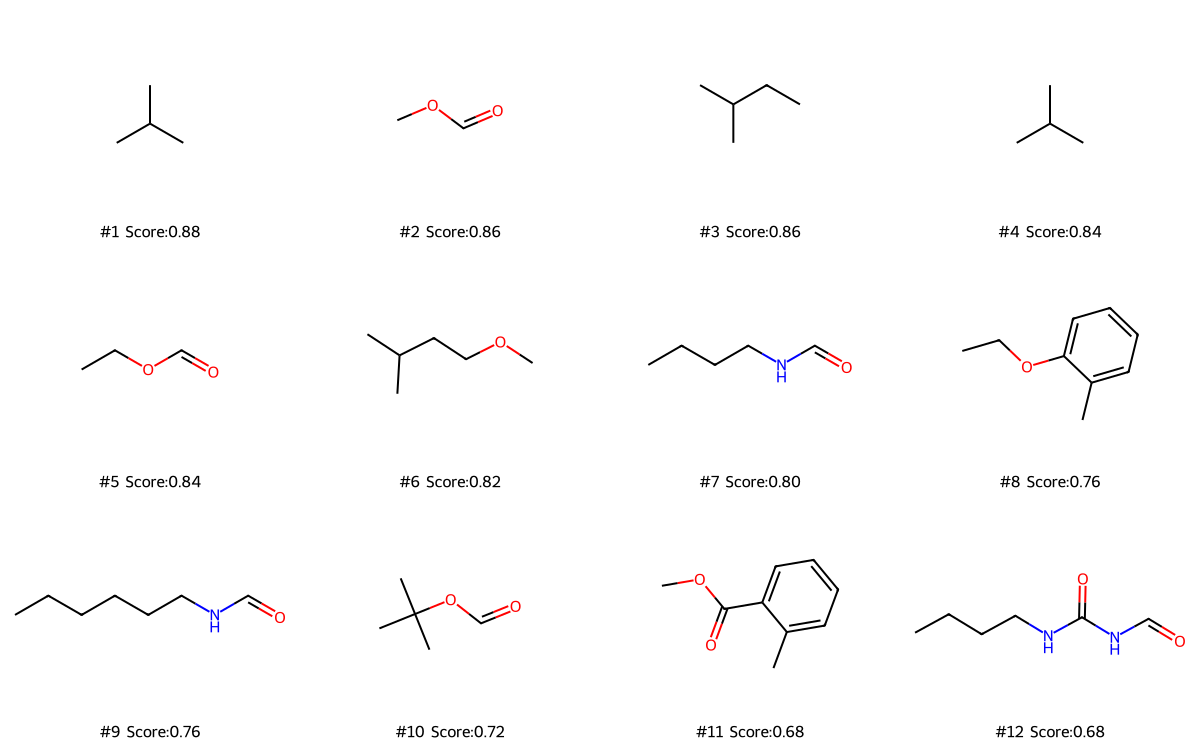

Saved: top12_molecules.png


In [38]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image # Import Image directly
import io

# Get top 12 rows from prop_df
top_rows = prop_df.head(12)

top12_mols = []
legends = []
for index, row in top_rows.iterrows():
    sm = row['SMILES']
    mol = Chem.MolFromSmiles(sm)
    if mol is not None:
        top12_mols.append(mol)
        legends.append(f'#{len(top12_mols)} Score:{row["FinalScore"]:.2f}')

# Generate image data as PNG bytes (it might be an IPython.display.Image object in Colab)
img_output = Draw.MolsToGridImage(
    top12_mols,
    molsPerRow=4,
    subImgSize=(300, 250),
    legends=legends,
    returnPNG=True  # Crucial for getting savable data
)

# Extract the actual binary data if img_output is an IPython.display.Image object
# Otherwise, it's already bytes
if isinstance(img_output, Image): # Use the directly imported Image class
    binary_image_data = img_output.data
else:
    binary_image_data = img_output

# Save the binary image data to a file
with open('top12_molecules.png', 'wb') as f:
    f.write(binary_image_data)

# To display in Colab, use IPython.display.Image with the binary data
display(Image(data=binary_image_data)) # Use the directly imported Image class
print('Saved: top12_molecules.png')

## 📋 CELL 12 — Export All Results to CSV

In [35]:
from rdkit.Chem import QED

qed_map = {}
for sm in valid_molecules:
    mol = Chem.MolFromSmiles(sm)
    if mol:
        qed_map[sm] = round(QED.qed(mol), 3)

prop_df['QED'] = prop_df['SMILES'].map(qed_map)
prop_df['IsNovel'] = prop_df['SMILES'].apply(lambda s: s not in set(smiles))
prop_df['IsDrugLike'] = prop_df['DrugScore'] >= 0.75

prop_df.to_csv('generated_molecules_full.csv', index=False)
print(f'Exported {len(prop_df)} molecules to generated_molecules_full.csv')
print('\nColumn list:', list(prop_df.columns))
prop_df.head(5)

Exported 18 molecules to generated_molecules_full.csv

Column list: ['SMILES', 'MolWeight', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'AromaticRings', 'DrugScore', 'Toxicity', 'FinalScore', 'QED', 'IsNovel', 'IsDrugLike']


,SMILES,MolWeight,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,DrugScore,Toxicity,FinalScore,QED,IsNovel,IsDrugLike
0,CC(C)C,58.12,1.66,0.0,0,0,0,0,1.0,0.12,0.88,0.397,True,True
1,COC(=O),60.05,-0.21,26.3,0,2,1,0,1.0,0.14,0.86,0.391,True,True
2,CC(C)CC,72.15,2.05,0.0,0,0,1,0,1.0,0.14,0.86,0.444,True,True
3,CC(C)(C),58.12,1.66,0.0,0,0,0,0,1.0,0.16,0.84,0.397,True,True
4,CCOC(=O),74.08,0.18,26.3,0,2,2,0,1.0,0.16,0.84,0.437,True,True
